# 量子回路ボルンマシン (Quantum Circuit Born Machine, QCBM)
量子回路ボルンマシンは、状態ベクトルを用いて機械学習における生成モデルを学習します。
学習に使う回路は、任意の1量子ビット回転ゲートとエンタングルメントゲートで構成されます。

### 生成モデル

生成モデルでは、学習したい確率分布と量子回路の測定結果の確率分布との差が小さくなるように学習を行います。

例えば、表が出る確率が $2/3$ のコインを学習したい場合、量子回路が"1"を測定する確率が $2/3$ になるようにします。

また、いびつな四面体のサイコロの各面が出る確率が $0.2, 0.4, 0.1, 0.3$ であることを学習したい場合、量子回路の出力状態が例えば $\lvert \psi \rangle = \sqrt{0.2}\lvert 00 \rangle + \sqrt{0.4}\lvert 01 \rangle + \sqrt{0.1}\lvert 10 \rangle + \sqrt{0.3}\lvert 11 \rangle$ となるように学習する必要があります。

### コスト関数

このような学習には、以下のコスト関数 $C(\theta)$ ($\theta$: 量子回路の回転角パラメータ)を使用します。

$$
C(\theta) = -\frac{1}{D}\sum^D_{d=1}\ln\bigl(\max(\epsilon, P_{\theta}(x^{(d)})) \bigr)
$$

$D$: データセットのサイズ。
$P_{\theta}(x)$: 量子回路からのサンプリングによってデータ $x$ が得られる確率。

データセットは、学習したい生成モデルからの決まった数の出力です。
例えば、上記の面が $\{1, 2, 3, 4\}$ である四面体のサイコロを仮定すると、10回分の出力からなるデータセットは $\{2, 4, 3, 1, 2, 2, 4, 1, 2, 4\}$ のようになります。

この損失関数を最小化することで分布間の差を最小化できる仕組みは以下の通りです。

$P_{\theta}(x^{(d)})\ (\leq 1)$ が大きいほど、$-\ln(P_{\theta}(x^{(d)}))$ は小さくなります。

したがって、元のデータセットでより頻繁に出現する $x^{(d)}$ について、量子回路の出力確率 $P_{\theta}(x^{(d)})$ を大きくすれば、損失関数を小さくすることができます。

損失関数は、量子回路出力の確率分布とデータセットの確率分布が等しいときに最小になります。

$\epsilon$ を導入する理由:
データセット中のあるデータ $x$ が、量子回路からのサンプリング結果に一度も含まれなかった場合、負の対数尤度関数は無限大になってしまいます。サンプリング回数は有限であるため、データセットにわずかしか含まれないデータについてこれが起こり得ます。
これを防ぐために、微小量 $\epsilon$ を導入します。

## 実装

今回は、簡単な例として、量子回路にガウス分布を学習させます。

Blueqatをインストールします。

In [ ]:
!pip install git+https://github.com/blueqat/blueqatSDK

### データセットの準備

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ガウス分布から500回サンプリングしてデータセットを作成します。
今回は4量子ビットの回路で学習するため、16分割した頻度分布を学習に使用します。

[  2.   2.  10.  27.  52. 100. 117. 174. 162. 128. 103.  68.  40.  10.
   4.   1.]


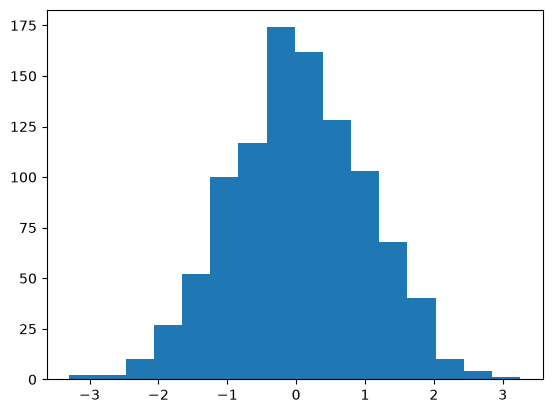

In [3]:
samples = np.random.normal(0, 1, 1000)

hist = plt.hist(samples, bins = 16)
data_prob = hist[0]
print(data_prob)

量子回路の16通りの出力($0000$から$1111$)の測定確率が、上記の頻度分布に対応します。
つまり、$0111$と$1000$の測定確率が確率分布の山であり、$0000$と$1111$の測定確率が確率分布の裾になります。

### 回路の準備
UゲートとCXゲートを使って、4量子ビットの回路を組んでみましょう。

```
|0> --U--*--------X--[繰り返し]--[m]
|0> --U--X--*-----|--[繰り返し]--[m]
|0> --U-----X--*--|--[繰り返し]--[m]
|0> --U--------X--*--[繰り返し]--[m]
```

パラメータの更新には勾配降下法を使用します。

3.8236594739343612
3.581051966556265
3.407732835791002
3.4249067219127243


3.3101804826268637
3.321737681548132
3.3402402054249256
3.2652697096626104


3.1851008949449278
3.1844200902707906
3.1745541780484343


3.260070533599699
3.1759373852775226
3.1071048631579985


3.0944737864551533
3.0810212678533473
3.0998104982809473


...

2.824312375279427
2.827300922409448
2.8738986657134764


2.808792399168395
2.850038746132413
2.751361047271263


2.755256743185084
2.6893471932984716
2.666292707304705


2.6815694781845107
2.648796749436555
2.628823763666942


2.648162777640115
2.6496243661360297


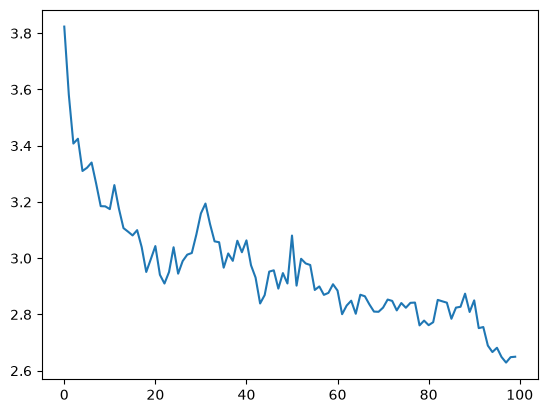

7.28760290145874


In [4]:
from blueqat import Circuit
import time

np.random.seed(30)

#initial parameters
param_init = [np.random.rand()*np.pi*2 for i in range(36)]

#1qubit state preparation
def arbi(para):
    circ1 = Circuit()
    circ1.u(para[0],para[1],para[2])[0]
    circ1.u(para[3],para[4],para[5])[1]
    circ1.u(para[6],para[7],para[8])[2]
    circ1.u(para[9],para[10],para[11])[3]
    return circ1
    
#cx loop circuit
def loop():
    circ2 = Circuit()
    circ2.cx[0,1]
    circ2.cx[1,2]
    circ2.cx[2,3]
    circ2.cx[3,0]
    return circ2

#QCBM circuit
def qcbm(a):
    u = Circuit()
    u += arbi(a[0:12])
    u += loop()
    u += arbi(a[12:24])
    u += loop()
    u += arbi(a[24:36])
    u += loop()
    return u

def nnl_loss(data, sampled, shots):
    D = np.sum(data)
    nnl_cost = 0
    eps = (1/shots)
    for i in range(16):
        key = format(i, '04b')
        prob = sampled[key] / shots
        cost = - np.log(max(eps, prob)) / D
        nnl_cost += cost * data[i]
    return nnl_cost

#initial parameters
param = param_init.copy()

#result list
loss_hist = []

h = 0.01
e = 0.01

#iterations
nsteps = 100

start = time.time()
shots = 4096

for i in range(nsteps):
    c = qcbm(param)
    res = c.m[:].run(shots = shots)
    loss = nnl_loss(data_prob, res, shots)

    print(loss)
    loss_hist.append(loss)

    new_param = [0 for i in range(len(param))]   
    for j in range(len(param)):
        _param = param.copy()
        _param[j] += h
        c = qcbm(_param)
        res = c.m[:].run(shots = shots)
        _loss = nnl_loss(data_prob, res, shots)
        new_param[j] = param[j] - e*(_loss - loss)/h

    param = new_param

plt.plot(loss_hist)
plt.show()

print(time.time() - start)

### 結果の確認

学習結果を確認しましょう。

今回は、学習前と学習後のパラメータについて、量子回路出力の確率分布を比較します。
学習後のパラメータでは、より正規分布に近くなっているはずです。

学習前のパラメータ。

In [5]:
c = qcbm(param_init)
res = c.m[:].run(shots = shots)

before_learning = []
for i in range(16):
    key = format(i, '04b')
    before_learning.append(res[key])

学習後のパラメータ。

In [6]:
c = qcbm(param)
res = c.m[:].run(shots = shots)

after_learning = []
for i in range(16):
    key = format(i, '04b')
    after_learning.append(res[key])

Text(0.5, 1.0, 'Output distribusion from parameters before learning')

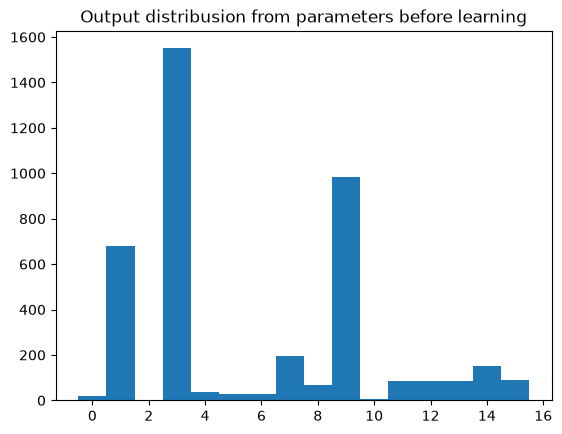

In [7]:
plt.bar([i for i in range(16)], before_learning, 1)
plt.title("Output distribusion from parameters before learning")

Text(0.5, 1.0, 'Output distribusion from parameters after learning')

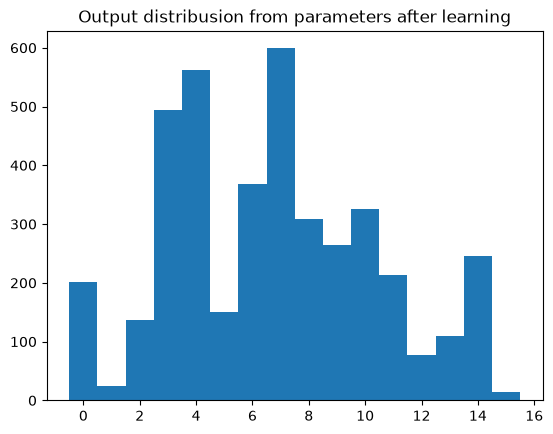

In [8]:
plt.bar([i for i in range(16)], after_learning, 1)
plt.title("Output distribusion from parameters after learning")

学習後の方が分布が正規分布に近くなっていることが分かります。今回は追求しませんが、まだきれいな正規分布からは程遠いため、パラメータの数、学習ステップ数、量子回路のハイパーパラメータなどに改善の余地があります。

これで、QCBMによって確率分布を学習できることが分かりました。